In [195]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [196]:
df = pd.read_csv('/content/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [197]:
df.shape

(8807, 12)

In [198]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [199]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [200]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [201]:
df.isna().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [202]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['date_added'].fillna(df['date_added'].mode()[0], inplace=True)

In [203]:
df['date_added']

,date_added
0,2021-09-25
1,2021-09-24
2,2021-09-24
3,2021-09-24
4,2021-09-24
...,...
8802,2019-11-20
8803,2019-07-01
8804,2019-11-01
8805,2020-01-11


In [204]:
df['country'].fillna('Unknown', inplace=True)
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['rating'].fillna('Unknown', inplace=True)

In [205]:
df.isna().sum()


,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,3


In [206]:
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)


<Axes: ylabel='count'>

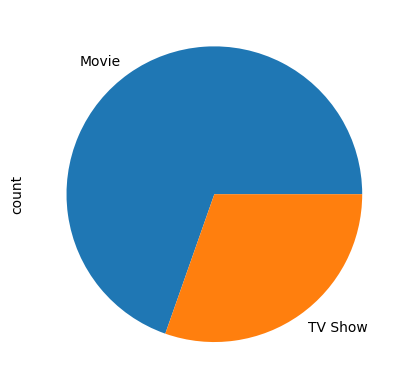

In [207]:
df["type"].value_counts().plot(kind = "pie")

<Axes: xlabel='type'>

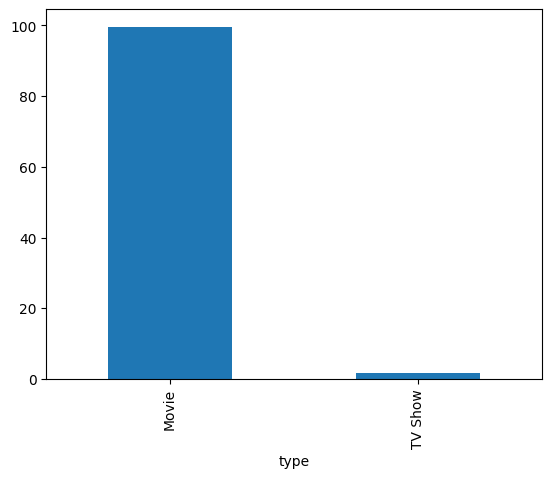

In [208]:
df.groupby('type')['duration_num'].mean().plot(kind='bar')

In [209]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_num
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2.0


# **models**

In [210]:
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])

# **Feature Extraction**



In [211]:
le_rating = LabelEncoder()
df['rating_encoded'] = le_rating.fit_transform(df['rating'])
df['month_added'] = pd.to_datetime(df['date_added']).dt.month
df['year_added'] = pd.to_datetime(df['date_added']).dt.year


# **Feature Engineering**

In [212]:
df['num_cast'] = df['cast'].apply(lambda x: len(x.split(',')) if x != 'Unknown' else 0)
df['num_genres'] = df['listed_in'].apply(lambda x: len(x.split(',')))
df['years_diff'] = df['year_added'] - df['release_year']

In [213]:
X = df[['release_year', 'month_added', 'year_added',
        'num_cast', 'num_genres', 'rating_encoded', 'years_diff']]
y = df['type']

In [214]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [215]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **LogisticRegression**

In [216]:
lr = LogisticRegression(class_weight='balanced')
lr.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced')

In [217]:
y_pred_lr = lr.predict(X_test_scaled)

In [218]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.83      0.61      0.70      1214
           1       0.45      0.73      0.56       548

    accuracy                           0.64      1762
   macro avg       0.64      0.67      0.63      1762
weighted avg       0.71      0.64      0.66      1762



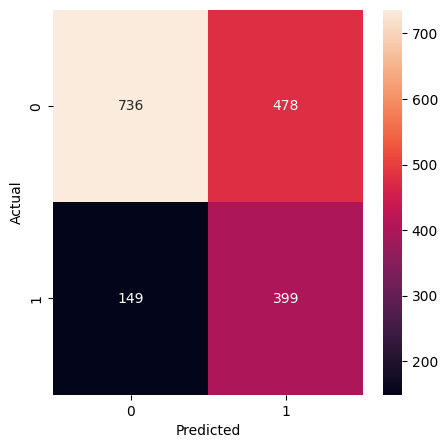

In [219]:
plt.figure(figsize=(5,5))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Decision Tree

In [220]:
dt = DecisionTreeClassifier(class_weight='balanced', max_depth=5)
dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5)

In [221]:
y_pred_dt = dt.predict(X_test)

In [222]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.78      0.83      0.80      1214
           1       0.56      0.49      0.52       548

    accuracy                           0.72      1762
   macro avg       0.67      0.66      0.66      1762
weighted avg       0.71      0.72      0.72      1762



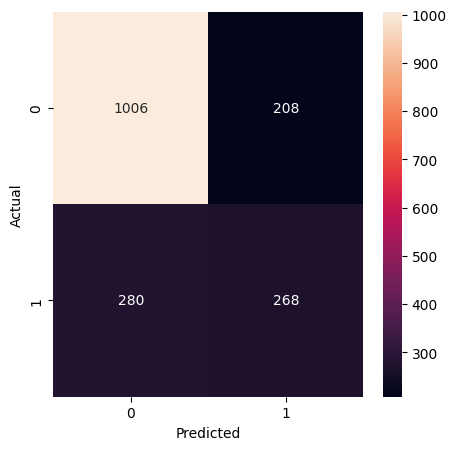

In [223]:
plt.figure(figsize=(5,5))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [224]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)


RandomForestClassifier()

In [225]:
y_pred_rf = rf.predict(X_test)

In [226]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.80      0.89      0.84      1214
           1       0.67      0.50      0.57       548

    accuracy                           0.77      1762
   macro avg       0.73      0.69      0.71      1762
weighted avg       0.76      0.77      0.76      1762



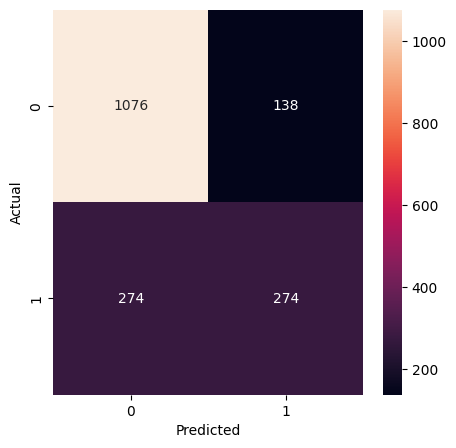

In [227]:
plt.figure(figsize=(5,5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='g')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **Linear Regression**

In [228]:
lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train)

LinearRegression()

In [229]:
y_pred_lr = lr_reg.predict(X_test)
y_pred_lr = [1 if i > 0.5 else 0 for i in y_pred_lr]

In [230]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.70      0.97      0.82      1214
           1       0.60      0.09      0.16       548

    accuracy                           0.70      1762
   macro avg       0.65      0.53      0.49      1762
weighted avg       0.67      0.70      0.61      1762



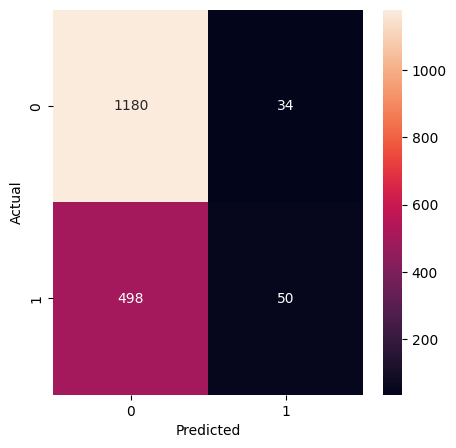

In [231]:
plt.figure(figsize=(5,5))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='g')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **knn**

In [232]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)


KNeighborsClassifier()

In [233]:
y_pred_knn = knn.predict(X_test_scaled)

In [234]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.79      0.86      0.83      1214
           1       0.62      0.50      0.56       548

    accuracy                           0.75      1762
   macro avg       0.71      0.68      0.69      1762
weighted avg       0.74      0.75      0.74      1762



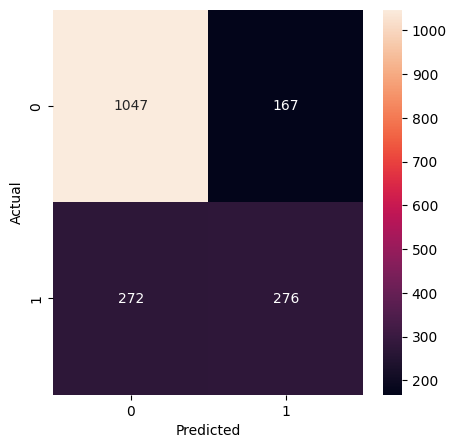

In [235]:
plt.figure(figsize=(5,5))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='g')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **naive bayes**

In [236]:
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)


GaussianNB()

In [237]:
y_pred_nb = nb.predict(X_test_scaled)

In [238]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.83      0.54      0.65      1214
           1       0.42      0.75      0.54       548

    accuracy                           0.61      1762
   macro avg       0.63      0.65      0.60      1762
weighted avg       0.70      0.61      0.62      1762



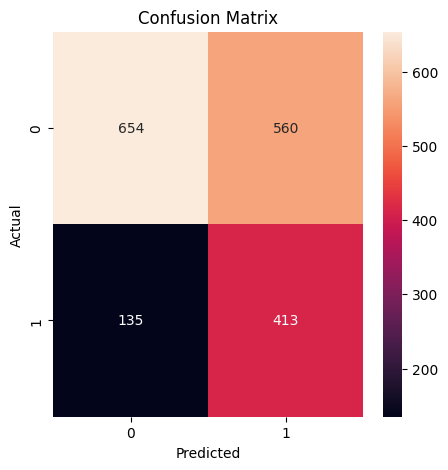

In [239]:
plt.figure(figsize=(5,5))
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='g')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [240]:
from sklearn.metrics import accuracy_score

results = {
    "Logistic": accuracy_score(y_test,y_pred_lr),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "Linear Regression": accuracy_score(y_test, y_pred_lr),
    "KNN": accuracy_score(y_test, y_pred_knn),
    "Naive Bayes": accuracy_score(y_test, y_pred_nb)
}

for model, acc in results.items():
    print(f"{model}: {acc:.2f}")

Logistic: 0.70
Decision Tree: 0.72
Random Forest: 0.77
Linear Regression: 0.70
KNN: 0.75
Naive Bayes: 0.61


# **Logistic Regression Scratch**




In [241]:
import numpy as np

class LogisticRegressionScratch:
    def __init__(self, lr=0.001, epochs=3000):
        self.lr = lr
        self.epochs = epochs

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])
        self.bias = 0

        for _ in range(self.epochs):
            linear = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(linear)

            dw = (1/len(y)) * np.dot(X.T, (y_pred - y))
            db = (1/len(y)) * np.sum(y_pred - y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        linear = np.dot(X, self.weights) + self.bias
        y_pred = self.sigmoid(linear)

        threshold = 0.4
        return np.array([1 if i > threshold else 0 for i in y_pred])

In [242]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [243]:
model = LogisticRegressionScratch(lr=0.001, epochs=3000)
model.fit(X_train_scaled, y_train.values)

y_pred_lr_s = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred_lr_s))

              precision    recall  f1-score   support

           0       0.85      0.52      0.65      1214
           1       0.43      0.80      0.56       548

    accuracy                           0.61      1762
   macro avg       0.64      0.66      0.60      1762
weighted avg       0.72      0.61      0.62      1762



# **KNN Scratch**

In [244]:
import numpy as np
from collections import Counter

class KNN_Scratch:
    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        predictions = [self._predict(x) for x in X]
        return np.array(predictions)

    def _predict(self, x):

        distances = [np.linalg.norm(x - x_train) for x_train in self.X_train]

        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]

        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

In [245]:
knn_s = KNN_Scratch(k=5)
knn_s.fit(X_train_scaled, y_train.values)

In [246]:
y_pred_knn_s = knn_s.predict(X_test_scaled)

In [247]:
print(classification_report(y_test, y_pred_knn_s))

              precision    recall  f1-score   support

           0       0.79      0.86      0.83      1214
           1       0.62      0.50      0.55       548

    accuracy                           0.75      1762
   macro avg       0.71      0.68      0.69      1762
weighted avg       0.74      0.75      0.74      1762



# **Naive Bayes Scratch**

In [248]:
import numpy as np

class NaiveBayesScratch:
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.mean = {}
        self.var = {}
        self.priors = {}

        for c in self.classes:
            X_c = X[y == c]
            self.mean[c] = np.mean(X_c, axis=0)
            self.var[c] = np.var(X_c, axis=0)
            self.priors[c] = X_c.shape[0] / X.shape[0]

    def predict(self, X):
        return np.array([self._predict(x) for x in X])

    def _predict(self, x):
        posteriors = []

        for c in self.classes:
            prior = np.log(self.priors[c])
            likelihood = np.sum(np.log(self._pdf(c, x)))
            posterior = prior + likelihood
            posteriors.append(posterior)

        return self.classes[np.argmax(posteriors)]

    def _pdf(self, c, x):
        mean = self.mean[c]
        var = self.var[c]
        numerator = np.exp(-(x - mean) ** 2 / (2 * var + 1e-9))
        denominator = np.sqrt(2 * np.pi * var + 1e-9)
        return numerator / denominator

In [249]:
nb_s = NaiveBayesScratch()
nb_s.fit(X_train_scaled, y_train.values)

In [250]:
y_pred_nb_s = nb_s.predict(X_test_scaled)

In [251]:
print(classification_report(y_test, y_pred_nb_s))

              precision    recall  f1-score   support

           0       0.83      0.54      0.65      1214
           1       0.42      0.75      0.54       548

    accuracy                           0.61      1762
   macro avg       0.63      0.65      0.60      1762
weighted avg       0.70      0.61      0.62      1762



# **Linear Regression Scratch**

In [252]:
class LinearRegressionScratch:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])
        self.bias = 0

        for _ in range(self.epochs):
            y_pred = np.dot(X, self.weights) + self.bias

            dw = (1/len(y)) * np.dot(X.T, (y_pred - y))
            db = (1/len(y)) * np.sum(y_pred - y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        y_pred = np.dot(X, self.weights) + self.bias
        return np.array([1 if i > 0.5 else 0 for i in y_pred])

In [253]:
class DecisionTreeScratch:
    def __init__(self, max_depth=5):
        self.max_depth = max_depth

    def fit(self, X, y):
        self.tree = self._build_tree(X, y)

    def _gini(self, y):
        classes = np.unique(y)
        impurity = 1
        for c in classes:
            p = np.sum(y == c) / len(y)
            impurity -= p ** 2
        return impurity

    def _best_split(self, X, y):
        best_feature, best_thresh = None, None
        best_gini = float('inf')

        for feature in range(X.shape[1]):
            thresholds = np.unique(X[:, feature])
            for t in thresholds:
                left = y[X[:, feature] <= t]
                right = y[X[:, feature] > t]

                if len(left) == 0 or len(right) == 0:
                    continue

                gini = (len(left)/len(y)) * self._gini(left) + \
                       (len(right)/len(y)) * self._gini(right)

                if gini < best_gini:
                    best_gini = gini
                    best_feature = feature
                    best_thresh = t

        return best_feature, best_thresh

    def _build_tree(self, X, y, depth=0):
        if len(set(y)) == 1 or depth >= self.max_depth:
            return np.bincount(y).argmax()

        feature, thresh = self._best_split(X, y)
        if feature is None:
            return np.bincount(y).argmax()

        left_idx = X[:, feature] <= thresh
        right_idx = X[:, feature] > thresh

        left = self._build_tree(X[left_idx], y[left_idx], depth+1)
        right = self._build_tree(X[right_idx], y[right_idx], depth+1)

        return (feature, thresh, left, right)

    def _predict_one(self, x, tree):
        if not isinstance(tree, tuple):
            return tree

        feature, thresh, left, right = tree

        if x[feature] <= thresh:
            return self._predict_one(x, left)
        else:
            return self._predict_one(x, right)

    def predict(self, X):
        return np.array([self._predict_one(x, self.tree) for x in X])

In [254]:
dt_s = DecisionTreeScratch(max_depth=5)
dt_s.fit(X_train_scaled, y_train.values)

In [255]:
dt_pred_s = dt_s.predict(X_test_scaled)

In [256]:
print(classification_report(y_test, dt_pred_s))

              precision    recall  f1-score   support

           0       0.73      0.95      0.83      1214
           1       0.69      0.24      0.35       548

    accuracy                           0.73      1762
   macro avg       0.71      0.59      0.59      1762
weighted avg       0.72      0.73      0.68      1762



In [257]:
class RandomForestScratch:
    def __init__(self, n_trees=10, max_depth=5):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.trees = []

    def _bootstrap(self, X, y):
        idxs = np.random.choice(len(X), len(X), replace=True)
        return X[idxs], y[idxs]

    def fit(self, X, y):
        self.trees = []
        for _ in range(self.n_trees):
            X_sample, y_sample = self._bootstrap(X, y)
            tree = DecisionTreeScratch(max_depth=self.max_depth)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def predict(self, X):
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        tree_preds = np.swapaxes(tree_preds, 0, 1)

        return np.array([np.bincount(row).argmax() for row in tree_preds])

In [258]:
rf_s = RandomForestScratch(n_trees=10, max_depth=5)
rf_s.fit(X_train_scaled, y_train.values)

In [259]:
y_pred_rf_s = rf_s.predict(X_test_scaled)

In [260]:
print(classification_report(y_test, y_pred_rf_s))

              precision    recall  f1-score   support

           0       0.74      0.95      0.83      1214
           1       0.71      0.27      0.39       548

    accuracy                           0.74      1762
   macro avg       0.73      0.61      0.61      1762
weighted avg       0.73      0.74      0.69      1762



In [261]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(y_test, y_pred):
    return [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ]

In [262]:
results = {
    "Logistic": evaluate(y_test, y_pred_lr),
    "Random Forest": evaluate(y_test, y_pred_rf),
    "KNN": evaluate(y_test, y_pred_knn),
    "Naive Bayes": evaluate(y_test, y_pred_nb)
}

In [263]:
import pandas as pd

df_results = pd.DataFrame(results, index=["Accuracy", "Precision", "Recall", "F1"])
print(df_results)

           Logistic  Random Forest       KNN  Naive Bayes
Accuracy   0.698070       0.766175  0.750851     0.605562
Precision  0.595238       0.665049  0.623025     0.424460
Recall     0.091241       0.500000  0.503650     0.753650
F1         0.158228       0.570833  0.557013     0.543064
